In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
# from skopt import gp_minimize
import gco
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy import ndimage
from scipy.ndimage import gaussian_filter

C:\Users\nujiz\anaconda3\Lib\site-packages\gco\__init__.py:7: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, name):


In [2]:
# !git checkout -b version-gco

# !git stash
# !git checkout version-gco
# !git stash apply

# !git branch -a

In [3]:
# !git add .
# !git commit -m "Deleted the maxflow"
# !git push

In [4]:
def plot_multiple(images, titles, colormap="gray", max_columns=np.inf, share_axes=True):
    """Plot multiple images as subplots on a grid."""
    assert len(images) == len(titles)
    n_images = len(images)
    n_cols = min(max_columns, n_images)
    n_rows = int(np.ceil(n_images / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4, n_rows * 4),
        squeeze=False,
        sharex=share_axes,
        sharey=share_axes,
    )

    axes = axes.flat
    # Hide subplots without content
    for ax in axes[n_images:]:
        ax.axis("off")

    if not isinstance(colormap, (list, tuple)):
        colormaps = [colormap] * n_images
    else:
        colormaps = colormap

    for ax, image, title, cmap in zip(axes, images, titles, colormaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)

    fig.tight_layout()

In [5]:
def gauss_derivs(img, sigma):
    grad_x = gaussian_filter(img, sigma, order=[0, 1]).flatten().reshape(-1, 1)
    grad_y = gaussian_filter(img, sigma, order=[1, 0]).flatten().reshape(-1, 1)
    dxx = gaussian_filter(img, sigma, order=[2, 0]).flatten().reshape(-1, 1)
    dyy = gaussian_filter(img, sigma, order=[0, 2]).flatten().reshape(-1, 1)
    dxy = gaussian_filter(img, sigma, order=[1, 1]).flatten().reshape(-1, 1)
    return grad_x, grad_y, dxx, dyy, dxy

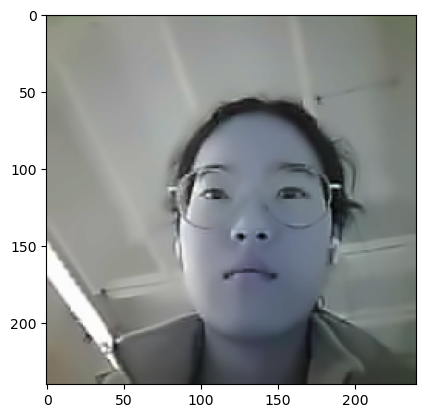

In [100]:
# Read and initialize
img = cv2.imread('Angelina_1746725609767.jpg')

h, w, c = img.shape
if h > 400:
    img = cv2.resize(img, (400, int(400/w*h)))
h, w, c = img.shape

img = cv2.fastNlMeansDenoisingColored(img, None, h=5, hColor=3, templateWindowSize=7, searchWindowSize=21)

plt.imshow(img)


rgb_flat = img.reshape(-1, 3).astype(np.float32)

# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
# plt.imshow(gray, cmap='gray')
# dx, dy, dxx, dyy, dxy = gauss_derivs(gray, 3.0)
# plot_multiple([dx.reshape(h, w), 
#                dy.reshape(h, w), 
#                dxx.reshape(h, w), 
#                dyy.reshape(h, w), 
#                dxy.reshape(h, w)], ['dx', 'dy', 'dxx', 'dyy', 'dxy'], max_columns=2)
# features = np.hstack((rgb_flat, dx, dy, dxx, dyy, dxy))

features = rgb_flat
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [101]:
# initialize for drawing
fg_mask = np.zeros((h, w), dtype=np.uint8)
bg_mask = np.zeros((h, w), dtype=np.uint8) # to store your seed strokes for foreground and background.

drawing = False
current_label = 'fg'  # or 'bg'

In [65]:
# def drawing func
def draw_seed(event, x, y, flags, param):
    global drawing, fg_mask, bg_mask, current_label

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        if current_label == 'fg':
            cv2.circle(fg_mask, (x, y), 10, 255, -1)
        elif current_label == 'bg':
            cv2.circle(bg_mask, (x, y), 10, 255, -1)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

In [102]:
# Window for drawing
cv2.namedWindow("Draw (press 'f' or 'b', then draw)")
cv2.setMouseCallback("Draw (press 'f' or 'b', then draw)", draw_seed)

print("Instructions:")
print(" - Press 'f' to draw foreground seeds")
print(" - Press 'b' to draw background seeds")
print(" - Press 's' to segment")
print(" - Press 'q' to quit")

while True:
    preview = img.copy()
    preview[fg_mask > 0] = [255, 255, 255]    # white = foreground
    preview[bg_mask > 0] = [0, 0, 0]      # black = background
    cv2.imshow("Draw (press 'f' or 'b', then draw)", preview)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('f'):
        current_label = 'fg'
        print("Drawing: foreground")
    elif key == ord('b'):
        current_label = 'bg'
        print("Drawing: background")
    elif key == ord('s'):
        break
    elif key == ord('q'):
        cv2.destroyAllWindows()
        exit()

cv2.destroyAllWindows()

Instructions:
 - Press 'f' to draw foreground seeds
 - Press 'b' to draw background seeds
 - Press 's' to segment
 - Press 'q' to quit
Drawing: background


In [32]:
# Data term (unary potentials)
def unary_potentials(probability_map, unary_weight):
    eps = 1e-10
    clipped_prob_map = np.clip(probability_map, eps, 1.0)
    return -unary_weight * np.log(probability_map)

def unary_costs(fg_mask, bg_mask, features, unary_weight):
    
    fg_inds = np.where(fg_mask.flatten() > 0)[0]
    bg_inds = np.where(bg_mask.flatten() > 0)[0]
    fg_pixels = features[fg_inds]
    bg_pixels = features[bg_inds]
    
    gmm_fg = GaussianMixture(n_components=3, covariance_type='full')
    gmm_bg = GaussianMixture(n_components=3, covariance_type='full')
    
    gmm_fg.fit(fg_pixels)
    gmm_bg.fit(bg_pixels)

    fg_prob = np.exp(gmm_fg.score_samples(features))
    bg_prob = np.exp(gmm_bg.score_samples(features))

    fg_prob = fg_prob.reshape(h, w)
    bg_prob = bg_prob.reshape(h, w)

    fg_cost = unary_potentials(fg_prob, unary_weight)  # ist umgekehrt when using maxflow
    bg_cost = unary_potentials(bg_prob, unary_weight)
    
    return fg_cost, bg_cost

In [33]:
# # smoothness with constant edges
# structure = np.array([[0, 1, 0],
#                       [1, 0, 1],
#                       [0, 1, 0]], dtype=np.int32)
# g.add_grid_edges(nodeids, weights=50.0, structure=structure, symmetric=True)

In [34]:
def pairwise_potential_prefactor(features, x1, y1, x2, y2, pairwise_weight):
    point1 = features[y1, x1]
    point2 = features[y2, x2]
    diff = np.linalg.norm(point1 - point2)
    return pairwise_weight*np.exp(-0.1*diff**2)
    
def coords_to_index(x, y, width):
    return y * width + x

def pairwise_potentials(features, pairwise_weight):
    features = features.astype(np.float32)
    height, width = features.shape[:2]
    edges = []
    costs = []

    for y in range(height):
        for x in range(width):
            index = coords_to_index(x, y, width)
            if x+1 < width:
                index_r = coords_to_index(x+1, y, width) # right neighbor
                edges.append([index, index_r])
                costs.append(pairwise_potential_prefactor(features, x, y, x+1, y, pairwise_weight))
            if y+1 < height:
                index_b = coords_to_index(x, y+1, width) # bottom neighbor
                edges.append([index, index_b])
                costs.append(pairwise_potential_prefactor(features, x, y, x, y+1, pairwise_weight))

    edges = np.array(edges, dtype=np.int32)
    costs = np.array(costs, dtype=np.float32)
    
    return edges, costs

In [103]:
features_2d = features.reshape(h, w, -1)
pairwise_edges, pairwise_costs = pairwise_potentials(features_2d, pairwise_weight=5)

In [46]:
def graph_cut(unary_fg, unary_bg, pairwise_edges, pairwise_costs):
    unaries = np.stack([unary_bg.flat, unary_fg.flat], axis=-1)
    labels = gco.cut_general_graph(
        pairwise_edges,
        pairwise_costs,
        unaries,
        1 - np.eye(2),
        n_iter=-1,
        algorithm="swap",
    )
    return labels.reshape(unary_fg.shape)

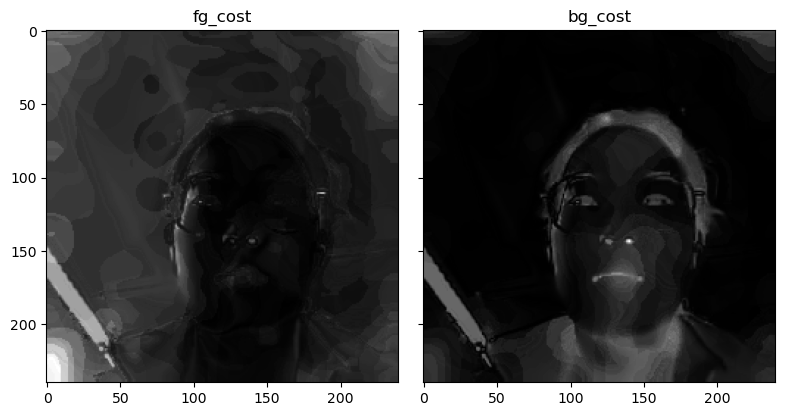

In [104]:
fg_cost, bg_cost = unary_costs(fg_mask, bg_mask, features, unary_weight=1)
plot_multiple([fg_cost, bg_cost], ['fg_cost', 'bg_cost'])
fg_mask_1 = graph_cut(fg_cost, bg_cost, pairwise_edges, pairwise_costs)
bg_mask_1 = 1 - fg_mask_1

In [112]:
def iterative_opt(
    fg_mask, bg_mask, img, pairwise_edges, pairwise_costs, unary_weight, n_iter
):
    h, w = img.shape[:2]
    for i in range(n_iter):
        
        img = cv2.fastNlMeansDenoisingColored(img, None, h=5, hColor=3, templateWindowSize=7, searchWindowSize=21)
        features = img.reshape(-1, 3)
        unary_fg, unary_bg = unary_costs(fg_mask, bg_mask, features, unary_weight)
        fg_mask = graph_cut(unary_fg, unary_bg, pairwise_edges, pairwise_costs)
        bg_mask = 1 - fg_mask

    return fg_mask, bg_mask

In [113]:
fg_mask_5, bg_mask_5 = iterative_opt(
    fg_mask_1, bg_mask_1, img, pairwise_edges, pairwise_costs, unary_weight=1, n_iter=5
)
fg_mask_10, bg_mask_10 = iterative_opt(
    fg_mask_1, bg_mask_1, img, pairwise_edges, pairwise_costs, unary_weight=1, n_iter=10
)

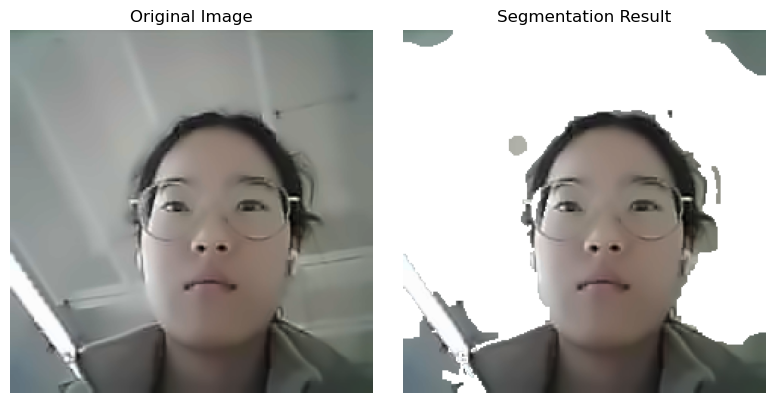

In [105]:
# Show results
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axs[0].imshow(img_rgb)
axs[0].set_title("Original Image")
axs[0].axis('off')

result_rgb = img_rgb.copy()
result_rgb[fg_mask_1 == 0] = [255, 255, 255]
axs[1].imshow(result_rgb)
axs[1].set_title("Segmentation Result")
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [38]:
fg_mask_20, bg_mask_20 = iterative_opt(
    fg_mask_10, bg_mask_10, features, pairwise_edges, pairwise_costs, unary_weight=1, n_iter=10
)

In [58]:
def result_img(img, mask):
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_img[mask == 0] = [255, 255, 255]
    return rgb_img

In [59]:
%matplotlib inline

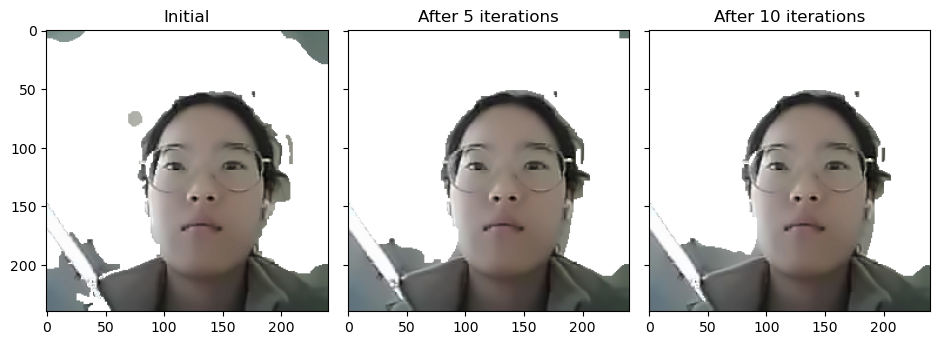

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 4), sharex=True, sharey=True)
axes[0].set_title("Initial")
axes[0].imshow(result_img(img, fg_mask_1))
axes[1].set_title("After 5 iterations")
axes[1].imshow(result_img(img, fg_mask_5))
axes[2].set_title("After 10 iterations")
axes[2].imshow(result_img(img, fg_mask_10))
fig.tight_layout()